In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "C:/Users/ACER/Downloads/test_set/test_set",
    validation_split=0.2,
    subset="training",  
    seed=123,            
    image_size=(150,150),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "C:/Users/ACER/Downloads/test_set/test_set",
    validation_split=0.2,
    subset="validation",  
    seed=123,             
    image_size=(150,150),
    batch_size=32
)

Found 2023 files belonging to 2 classes.
Using 1619 files for training.
Found 2023 files belonging to 2 classes.
Using 404 files for validation.


In [9]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [13]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')  
])

In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - accuracy: 0.5102 - loss: 0.7396 - val_accuracy: 0.4901 - val_loss: 0.6922
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step - accuracy: 0.5460 - loss: 0.6897 - val_accuracy: 0.6188 - val_loss: 0.6745
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 152ms/step - accuracy: 0.6115 - loss: 0.6689 - val_accuracy: 0.6040 - val_loss: 0.6638
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 168ms/step - accuracy: 0.6368 - loss: 0.6426 - val_accuracy: 0.6238 - val_loss: 0.6505
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 188ms/step - accuracy: 0.6671 - loss: 0.6071 - val_accuracy: 0.6040 - val_loss: 0.6599
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 188ms/step - accuracy: 0.7116 - loss: 0.5601 - val_accuracy: 0.6881 - val_loss: 0.6171
Epoch 7/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 186ms/step - accuracy: 0.7641 - loss: 0.4958 - val_accuracy: 0.6881 - val_loss: 0.5943
Epoch 8/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 187ms/step - accuracy: 0.8048 - loss: 0.4210 - val_accuracy

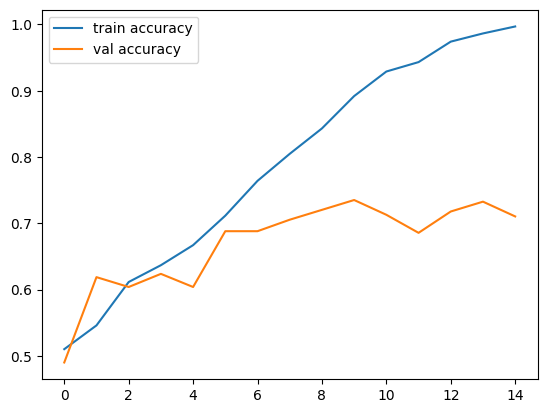

In [16]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.show()

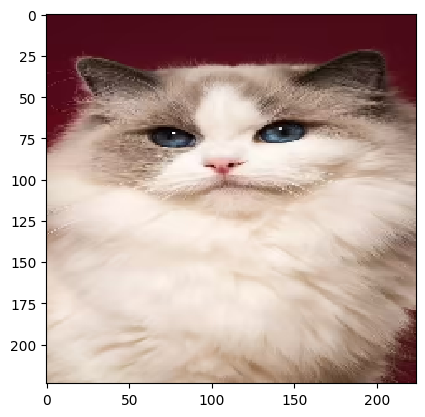

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Cat 🐱


In [19]:
path =r'C:\Users\ACER\Downloads\107091667.avif'
img = image.load_img(path,target_size=(224,224))
plt.imshow(img,interpolation='nearest')
plt.show()

img = image.load_img(r'C:\Users\ACER\Downloads\107091667.avif', target_size=(150,150))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Dog 🐶")
else:
    print("Cat 🐱")